In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations
from cloelib.cosmology.jax_cosmology import JAXBackground, JAXLinearPerturbations, JAXNonLinearPerturbations
from cloelib.cosmology.cosmology import Background

# Validation benchmark in astropy
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# Background quantities

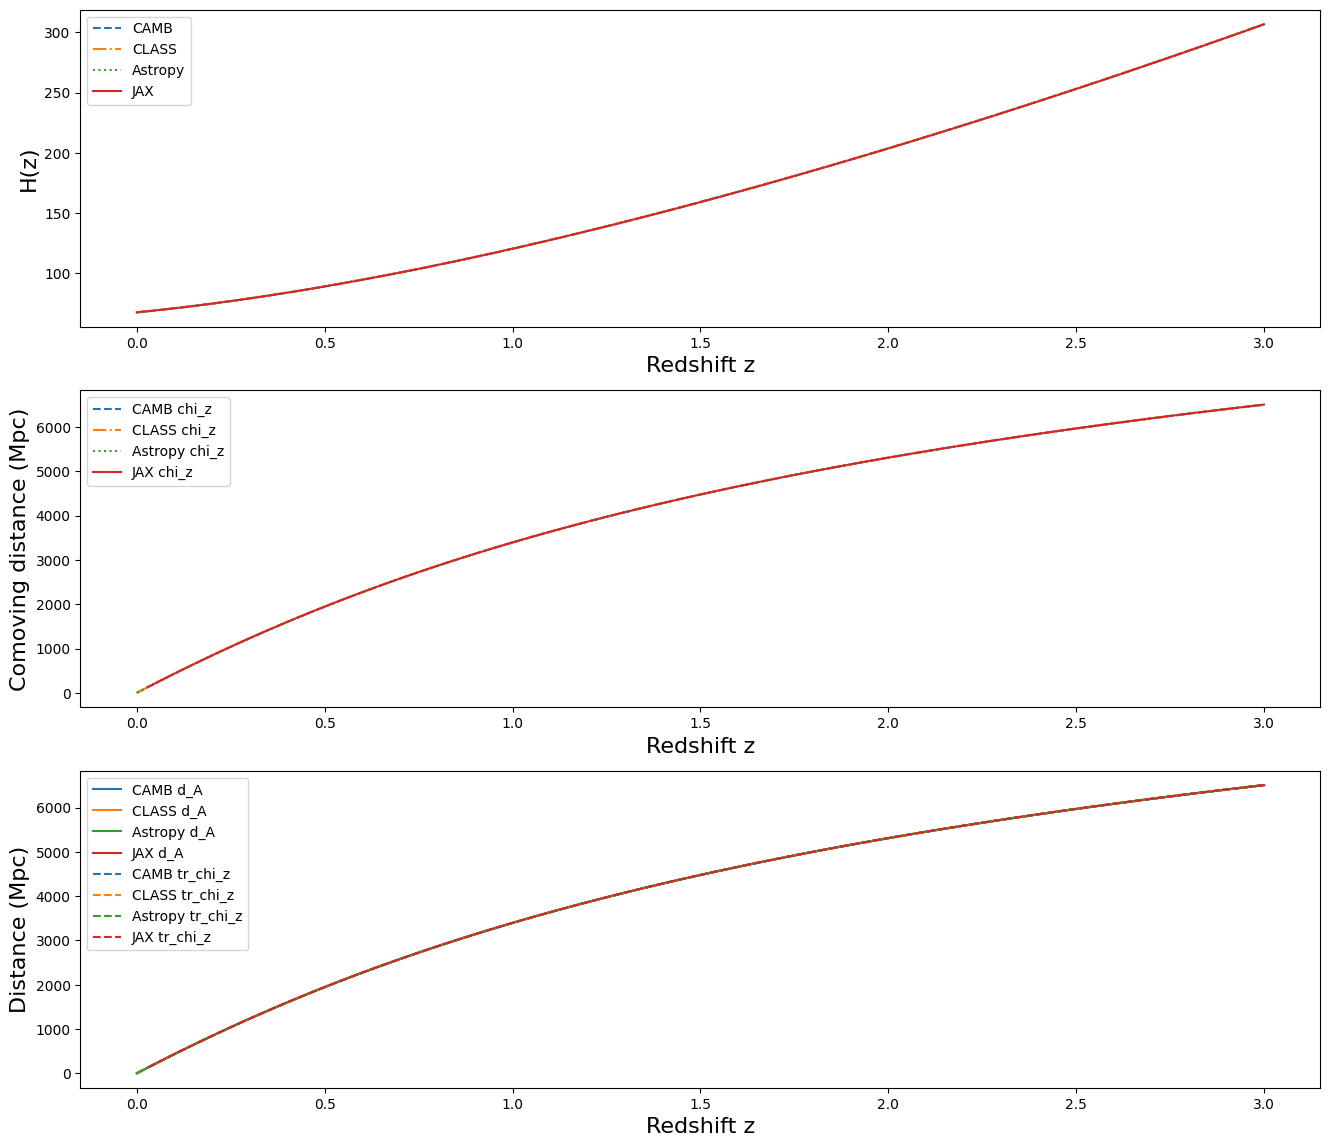

In [2]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
Omega_cdm0 = omch2/h**2
ombh2 = 0.022
Omega_b0 = ombh2/h**2
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.96
mnu = 0.
As=2e-9

# Astropy
Tcmb = 2.7255
Neff = 0.0#3.046
YHe = 0.2454

# z-array
z = np.linspace(0, 3, 100)

astropy_instance = FlatLambdaCDM(H0=H0,Om0=(Omega_cdm0 + Omega_b0),Ob0=Omega_b0, Tcmb0=Tcmb,Neff=Neff, m_nu=[0,0,0.0]*u.eV)
H_z_astropy = astropy_instance.H(z).to(u.km/u.s/u.Mpc).value
chi_z_astropy = astropy_instance.comoving_distance(z)
dA_z_astropy = astropy_instance.angular_diameter_distance(z)
tr_z_astropy = astropy_instance.comoving_transverse_distance(z)

camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')
chi_z_camb = camb_instance.comoving_distance(z)
dA_z_camb = camb_instance.angular_diameter_distance(z)
tr_z_camb = camb_instance.transverse_comoving_distance(z)

class_instance = CLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)
H_z_class = class_instance.hubble_parameter(z)
chi_z_class = class_instance.comoving_distance(z)
dA_z_class = class_instance.angular_diameter_distance(z)
tr_z_class = class_instance.transverse_comoving_distance(z)

jax_instance = JAXBackground(H0=H0,Omega_b0=Omega_b0,Omega_cdm0=Omega_cdm0, 
                             Omega_k0=Omega_k0,
                             As=As, ns=ns, mnu=mnu, w0=w, wa=wa, gamma_MG=0.)
H_z_jax = jax_instance.hubble_parameter(z)
chi_z_jax = jax_instance.comoving_distance(z)
dA_z_jax = jax_instance.angular_diameter_distance(z)
tr_z_jax = jax_instance.transverse_comoving_distance(z)

fig, axs = plt.subplots(figsize = (16,14), nrows=3, ncols=1)
axs[0].plot(z, H_z_camb, label = 'CAMB', ls='--')
axs[0].plot(z, H_z_class, label = 'CLASS', ls='-.')
axs[0].plot(z, H_z_astropy, label = 'Astropy', ls=':')
axs[0].plot(z, H_z_jax, label = 'JAX', ls='-')
axs[0].set_ylabel('H(z)', fontsize = 16)
axs[0].set_xlabel('Redshift z', fontsize = 16)
axs[0].legend()
axs[1].plot(z, chi_z_camb, label = 'CAMB chi_z', ls='--')
axs[1].plot(z, chi_z_class, label = 'CLASS chi_z', ls='-.')
axs[1].plot(z, chi_z_astropy, label = 'Astropy chi_z', ls=':')
axs[1].plot(z, chi_z_jax, label = 'JAX chi_z', ls='-')
axs[1].set_ylabel('Comoving distance (Mpc)', fontsize = 16)
axs[1].set_xlabel('Redshift z', fontsize = 16)
axs[1].legend()
axs[2].plot(z, dA_z_camb*(1+z), label = 'CAMB d_A', ls='-')
axs[2].plot(z, dA_z_class*(1+z), label = 'CLASS d_A', ls='-')
axs[2].plot(z, dA_z_astropy*(1+z), label = 'Astropy d_A', ls='-')
axs[2].plot(z, dA_z_jax*(1+z), label = 'JAX d_A', ls='-')
axs[2].set_ylabel('Distance (Mpc)', fontsize = 16)
plt.gca().set_prop_cycle(None)
axs[2].plot(z, tr_z_camb, label = 'CAMB tr_chi_z', ls='--')
axs[2].plot(z, tr_z_class, label = 'CLASS tr_chi_z', ls='--')
axs[2].plot(z, tr_z_astropy, label = 'Astropy tr_chi_z', ls='--')
axs[2].plot(z, tr_z_jax, label = 'JAX tr_chi_z', ls='--')
axs[2].set_xlabel('Redshift z', fontsize = 16)
axs[2].legend()

#Differences are due to neutrinos

## Check if Cosmology Classes are part of Background protocol

In [3]:
import os
import sys

# Add the parent of parent directory (playground) to Python path
# Add the protocols_test directory to Python path
protocols_test_dir = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'protocols_test')
sys.path.append(protocols_test_dir)

# Now import from protocols_test
from compliance import check_protocol_compliance
check_protocol_compliance(class_instance, Background, verbose=False)
check_protocol_compliance(camb_instance, Background, verbose=False)
check_protocol_compliance(jax_instance, Background, verbose=False)



CLASSBackground matches Background

CAMBBackground matches Background

JAXBackground matches Background


In [4]:
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)

Text(0.5, 1.0, 'JAX Perturbations')

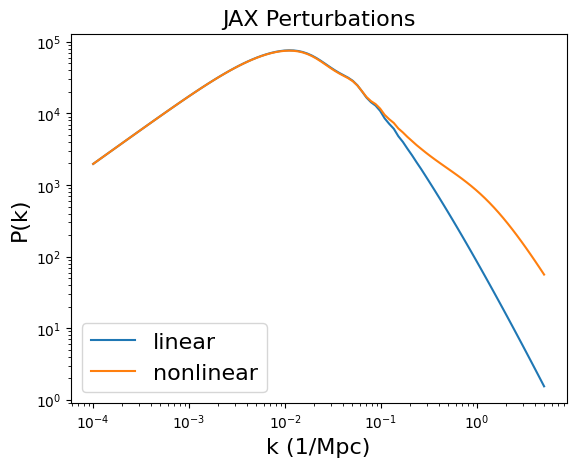

In [5]:
# JAX PERTURBATIONS
# k-array
jax_linear = JAXLinearPerturbations(background=jax_instance, redshifts=z)
jax_nonlinear = JAXNonLinearPerturbations(linearperturbations=jax_linear)
linear_pk_jax = jax_linear.matter_power_spectrum(z, ks)
nonlinear_pk_jax = jax_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_jax[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_jax[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("JAX Perturbations", fontsize = 16)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


Text(0.5, 1.0, 'CAMB Power Spectrum')

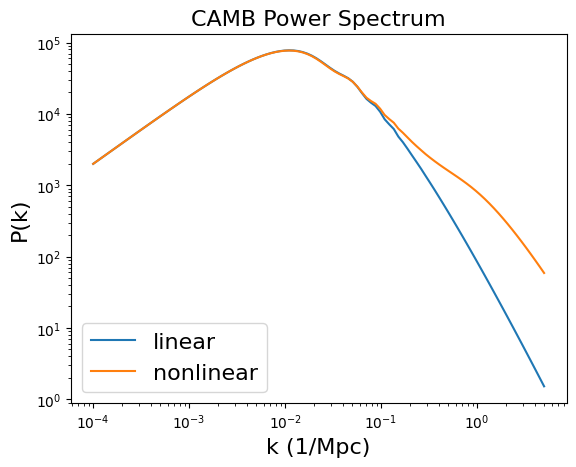

In [6]:
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, 
                                            nonlinear_model='mead2016')

linear_pk_camb = camb_linear.matter_power_spectrum(z, ks)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_camb[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_camb[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB Power Spectrum", fontsize = 16)

Text(0.5, 1.0, 'CLASS Perturbations')

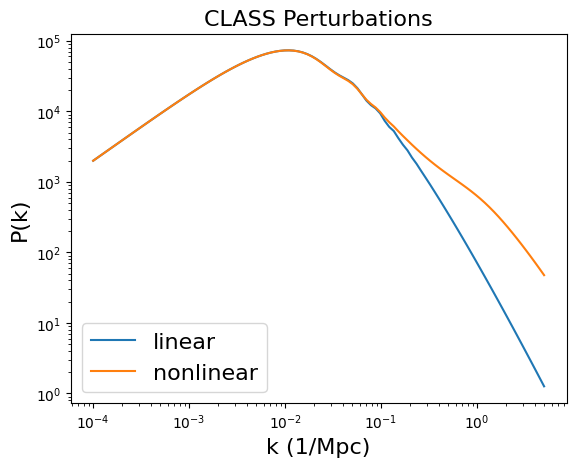

In [7]:
# CLASS PERTURBATIONS
# k-array
class_linear = CLASSLinearPerturbations(background=class_instance, redshifts=z)
class_nonlinear = CLASSNonLinearPerturbations(background=class_instance, 
                                              redshifts=z, 
                                              nonlinear_model='hmcode16')
linear_pk_class = class_linear.matter_power_spectrum(z, ks)
nonlinear_pk_class = class_nonlinear.matter_power_spectrum(z, ks)
plt.loglog(ks, linear_pk_class[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_class[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CLASS Perturbations", fontsize = 16)

Text(0.5, 1.0, 'CAMB vs. CLASS vs. JAX Linear Perturbations')

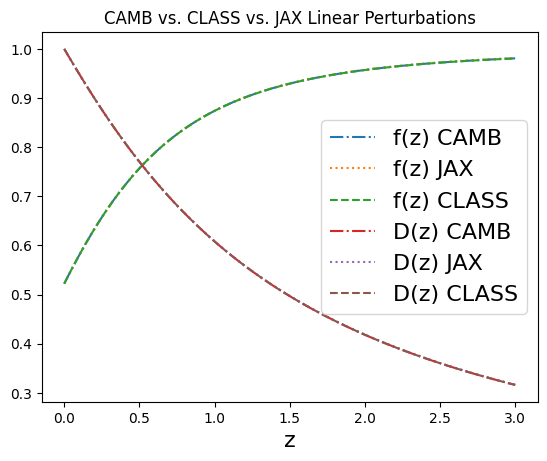

In [10]:
#calculate results for these parameters
plt.plot(z, camb_linear.growth_rate(), label = 'f(z) CAMB', ls='-.')
plt.plot(z, jax_linear.growth_rate(z), label = 'f(z) JAX', ls=':')
plt.plot(z, class_linear.growth_rate(), label = 'f(z) CLASS', ls='--')
plt.plot(z, camb_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CAMB', ls='-.')
plt.plot(z, jax_linear.growth_factor(z), label = 'D(z) JAX', ls=':')
plt.plot(z, class_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CLASS', ls='--')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB vs. CLASS vs. JAX Linear Perturbations")